# Warehouse ISAC Array Sweep Analysis

This notebook separates the metrics into the parts that answer different questions:

- **Static flow metrics**: best for showing `2x2 -> 4x4 -> 8x8` flow-performance improvement or saturation under controlled geometry.
- **Robot flow metrics**: mobility stress case; these can be non-monotonic because robot routes, command timing, retransmissions, and channel exposure vary over time.
- **Radio/propagation metrics**: CQI, MCS, pathloss, and array gain; these are the cleanest evidence for larger gNB arrays improving link quality.
- **ISAC sensing metrics**: raw and deduplicated detections; these are the direct ISAC benefit metrics.

Set `RESULT_DIR` to the sweep directory you want to analyze, then run all cells.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

RESULT_DIR = Path("/home/aung/code/docte6g/results/warehouse-v3-180s")
ARRAY_ORDER = ["2x2", "4x4", "8x8"]
MODE_ORDER = ["no-isac", "isac"]

assert RESULT_DIR.exists(), f"Missing result directory: {RESULT_DIR}"
RESULT_DIR

PosixPath('/home/aung/code/docte6g/results/warehouse-v3-180s')

## Helpers

Challenge traffic is split by destination port:

- `12000-12999`: static package/rack/sensor benchmark flows
- `13000-13999`: robot camera/mobile challenge flows
- `14000-15999`: reserved challenge range, reported as `other_challenge` if present

In [2]:
def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)


def discover_cases(result_dir: Path) -> pd.DataFrame:
    rows = []
    pattern = re.compile(r"^(no-isac|isac)-(\d+)x(\d+)$")
    for path in sorted(result_dir.iterdir()):
        if not path.is_dir():
            continue
        match = pattern.match(path.name)
        if not match:
            continue
        mode, rows_n, cols_n = match.groups()
        rows.append({
            "mode": mode,
            "array": f"{rows_n}x{cols_n}",
            "array_size": int(rows_n) * int(cols_n),
            "array_rows": int(rows_n),
            "array_cols": int(cols_n),
            "case": path.name,
            "path": path,
        })
    cases = pd.DataFrame(rows)
    if cases.empty:
        raise RuntimeError(f"No sweep cases found under {result_dir}")
    cases["mode"] = pd.Categorical(cases["mode"], MODE_ORDER, ordered=True)
    cases["array"] = pd.Categorical(cases["array"], ARRAY_ORDER, ordered=True)
    return cases.sort_values(["mode", "array_size"]).reset_index(drop=True)


def classify_flow_port(port: int) -> str:
    if 12000 <= port < 13000:
        return "static"
    if 13000 <= port < 14000:
        return "robot"
    if 14000 <= port < 16000:
        return "other_challenge"
    return "non_challenge"


def weighted_delivery_pct(group: pd.DataFrame) -> float:
    tx = group["TxPackets"].sum()
    return 100.0 * group["RxPackets"].sum() / tx if tx else np.nan


def monotonic_non_decreasing(values, tolerance=1e-9) -> bool:
    values = [v for v in values if pd.notna(v)]
    return all(right + tolerance >= left for left, right in zip(values, values[1:]))


cases = discover_cases(RESULT_DIR)
cases[["mode", "array", "case", "path"]]

,mode,array,case,path
0,no-isac,2x2,no-isac-2x2,/home/aung/code/docte6g/results/warehouse-v3-1...
1,no-isac,4x4,no-isac-4x4,/home/aung/code/docte6g/results/warehouse-v3-1...
2,no-isac,8x8,no-isac-8x8,/home/aung/code/docte6g/results/warehouse-v3-1...
3,isac,2x2,isac-2x2,/home/aung/code/docte6g/results/warehouse-v3-1...
4,isac,4x4,isac-4x4,/home/aung/code/docte6g/results/warehouse-v3-1...
5,isac,8x8,isac-8x8,/home/aung/code/docte6g/results/warehouse-v3-1...


## Flow Summary

Use the static rows for the clean array-size flow-performance claim. Use robot rows as a separate mobility stress result.

In [3]:
def summarize_flows(cases: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_flows = []
    summaries = []
    for case in cases.itertuples(index=False):
        flows = read_csv(Path(case.path) / "flow_stats.csv")
        if flows.empty:
            continue
        flows["flow_class"] = flows["DstPort"].astype(int).map(classify_flow_port)
        flows = flows[flows["flow_class"] != "non_challenge"].copy()
        if flows.empty:
            continue
        flows["mode"] = case.mode
        flows["array"] = case.array
        flows["array_size"] = case.array_size
        flows["case"] = case.case
        all_flows.append(flows)

        for flow_class, group in flows.groupby("flow_class", sort=False):
            summaries.append({
                "mode": case.mode,
                "array": case.array,
                "array_size": case.array_size,
                "flow_class": flow_class,
                "flows": len(group),
                "tx_packets": int(group["TxPackets"].sum()),
                "rx_packets": int(group["RxPackets"].sum()),
                "lost_packets": int(group["LostPackets"].sum()),
                "delivery_pct": weighted_delivery_pct(group),
                "goodput_kbps": group["SimGoodput_Kbps"].sum(),
                "mean_delay_ms": group["Delay_ms"].replace([np.inf, -np.inf], np.nan).mean(),
                "mean_jitter_ms": group["Jitter_ms"].replace([np.inf, -np.inf], np.nan).mean(),
            })
    flow_detail = pd.concat(all_flows, ignore_index=True) if all_flows else pd.DataFrame()
    flow_summary = pd.DataFrame(summaries)
    if not flow_summary.empty:
        flow_summary["mode"] = pd.Categorical(flow_summary["mode"], MODE_ORDER, ordered=True)
        flow_summary["array"] = pd.Categorical(flow_summary["array"], ARRAY_ORDER, ordered=True)
        flow_summary = flow_summary.sort_values(["flow_class", "mode", "array_size"]).reset_index(drop=True)
    return flow_detail, flow_summary


flow_detail, flow_summary = summarize_flows(cases)
flow_summary

,mode,array,array_size,flow_class,flows,tx_packets,rx_packets,lost_packets,delivery_pct,goodput_kbps,mean_delay_ms,mean_jitter_ms
0,no-isac,2x2,4,robot,3,480000,436407,43593,90.918125,23259.71,18.666667,0.000000
1,no-isac,4x4,16,robot,3,480000,365859,114141,76.220625,19499.77,15.666667,0.000000
2,no-isac,8x8,64,robot,3,480000,407974,72026,84.994583,21744.45,10.666667,0.000000
3,isac,2x2,4,robot,3,480000,394460,85540,82.179167,21023.93,20.666667,0.000000
4,isac,4x4,16,robot,3,480000,409381,70619,85.287708,21819.44,15.000000,0.000000
5,isac,8x8,64,robot,3,480000,407358,72642,84.866250,21711.61,11.000000,0.000000
6,no-isac,2x2,4,static,3,480000,476467,3533,99.263958,25395.03,45.000000,0.333333
7,no-isac,4x4,16,static,3,480000,479866,134,99.972083,25576.19,11.000000,0.000000
8,no-isac,8x8,64,static,3,480000,479963,37,99.992292,25581.35,10.000000,0.000000
9,isac,2x2,4,static,3,480000,476526,3474,99.276250,25398.17,44.000000,0.333333


In [4]:
flow_table = (
    flow_summary
    .pivot_table(index=["mode", "array"], columns="flow_class", values=["delivery_pct", "goodput_kbps"], observed=False)
    .round(3)
)
flow_table

delivery_pct         goodput_kbps          
flow_class           robot  static        robot    static
mode    array                                            
no-isac 2x2         90.918  99.264     23259.71  25395.03
        4x4         76.221  99.972     19499.77  25576.19
        8x8         84.995  99.992     21744.45  25581.35
isac    2x2         82.179  99.276     21023.93  25398.17
        4x4         85.288  99.974     21819.44  25576.61
        8x8         84.866  99.991     21711.61  25580.93

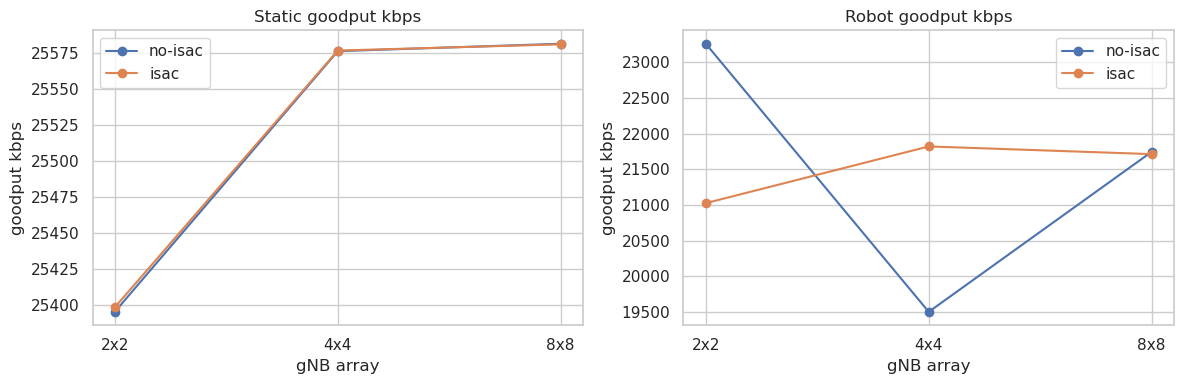

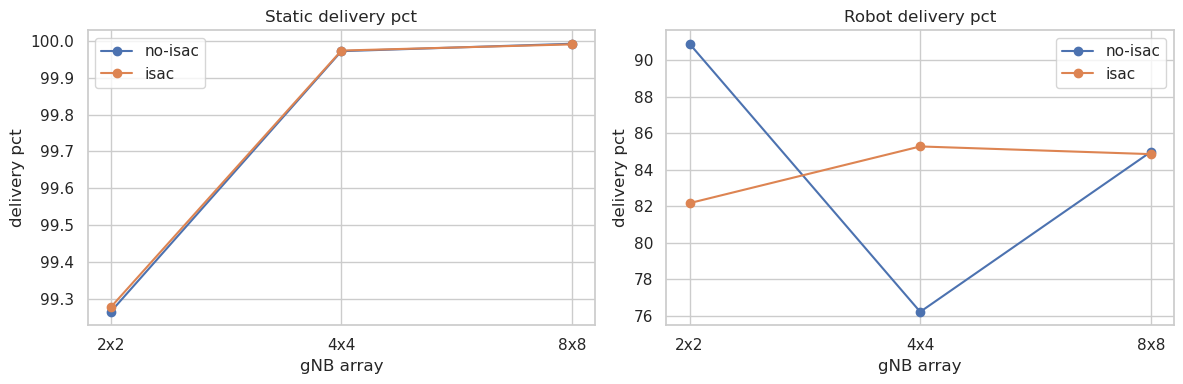

In [5]:
for metric in ["goodput_kbps", "delivery_pct"]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for ax, flow_class in zip(axes, ["static", "robot"]):
        data = flow_summary[flow_summary["flow_class"] == flow_class]
        if data.empty:
            ax.set_visible(False)
            continue
        for mode, group in data.groupby("mode", observed=True):
            group = group.sort_values("array_size")
            ax.plot(group["array"].astype(str), group[metric], marker="o", label=str(mode))
        ax.set_title(f"{flow_class.title()} {metric.replace('_', ' ')}")
        ax.set_xlabel("gNB array")
        ax.set_ylabel(metric.replace("_", " "))
        ax.legend()
    fig.tight_layout()
    plt.show()

## Radio and Propagation Summary

These metrics should be used for the antenna-array claim because they are closer to the physical link than the full application workflow.

In [6]:
def summarize_radio(cases: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for case in cases.itertuples(index=False):
        run_dir = Path(case.path)
        radio = read_csv(run_dir / "radio_link_stats.csv")
        cqi = read_csv(run_dir / "cqi_feedback_stats.csv")
        propagation = read_csv(run_dir / "propagation_stats.csv")
        gains = read_csv(run_dir / "mimo_channel_gain_stats.csv")

        source = radio if not radio.empty else cqi
        if not source.empty:
            sample_col = "CqiSamples" if "CqiSamples" in source.columns else "Samples"
            weights = source[sample_col].replace(0, np.nan)
            mean_cqi = np.average(source["MeanCqi"], weights=weights) if weights.notna().any() else source["MeanCqi"].mean()
            mean_mcs = np.average(source["MeanMcs"], weights=weights) if weights.notna().any() else source["MeanMcs"].mean()
            min_mcs = source["MinMcs"].min()
            max_mcs = source["MaxMcs"].max()
            mean_est_sinr_db = source["MeanEstimatedSinrFromCqi_dB"].mean() if "MeanEstimatedSinrFromCqi_dB" in source else np.nan
        else:
            mean_cqi = mean_mcs = min_mcs = max_mcs = mean_est_sinr_db = np.nan

        rows.append({
            "mode": case.mode,
            "array": case.array,
            "array_size": case.array_size,
            "mean_cqi": mean_cqi,
            "mean_mcs": mean_mcs,
            "min_mcs": min_mcs,
            "max_mcs": max_mcs,
            "mean_est_sinr_db": mean_est_sinr_db,
            "mean_pathloss_db": propagation["Pathloss_dB"].mean() if not propagation.empty and "Pathloss_dB" in propagation else np.nan,
            "mean_loss_db": propagation["Loss_dB"].mean() if not propagation.empty and "Loss_dB" in propagation else np.nan,
            "mean_array_gain_db": gains["AvgEffectiveChannelGain_dB"].mean() if not gains.empty and "AvgEffectiveChannelGain_dB" in gains else np.nan,
        })
    summary = pd.DataFrame(rows)
    summary["mode"] = pd.Categorical(summary["mode"], MODE_ORDER, ordered=True)
    summary["array"] = pd.Categorical(summary["array"], ARRAY_ORDER, ordered=True)
    return summary.sort_values(["mode", "array_size"]).reset_index(drop=True)


radio_summary = summarize_radio(cases)
radio_summary.round(3)

,mode,array,array_size,mean_cqi,mean_mcs,min_mcs,max_mcs,mean_est_sinr_db,mean_pathloss_db,mean_loss_db,mean_array_gain_db
0,no-isac,2x2,4,10.485,18.372,0,27,13.604,77.607,77.607,12.041
1,no-isac,4x4,16,13.298,23.912,0,27,19.318,77.593,77.593,18.062
2,no-isac,8x8,64,14.276,25.810,0,27,21.458,77.039,77.039,24.082
3,isac,2x2,4,10.330,18.204,0,27,13.446,77.059,77.059,12.041
4,isac,4x4,16,13.385,24.069,0,27,19.487,77.103,77.103,18.062
5,isac,8x8,64,14.280,25.820,0,27,21.468,77.170,77.170,24.082


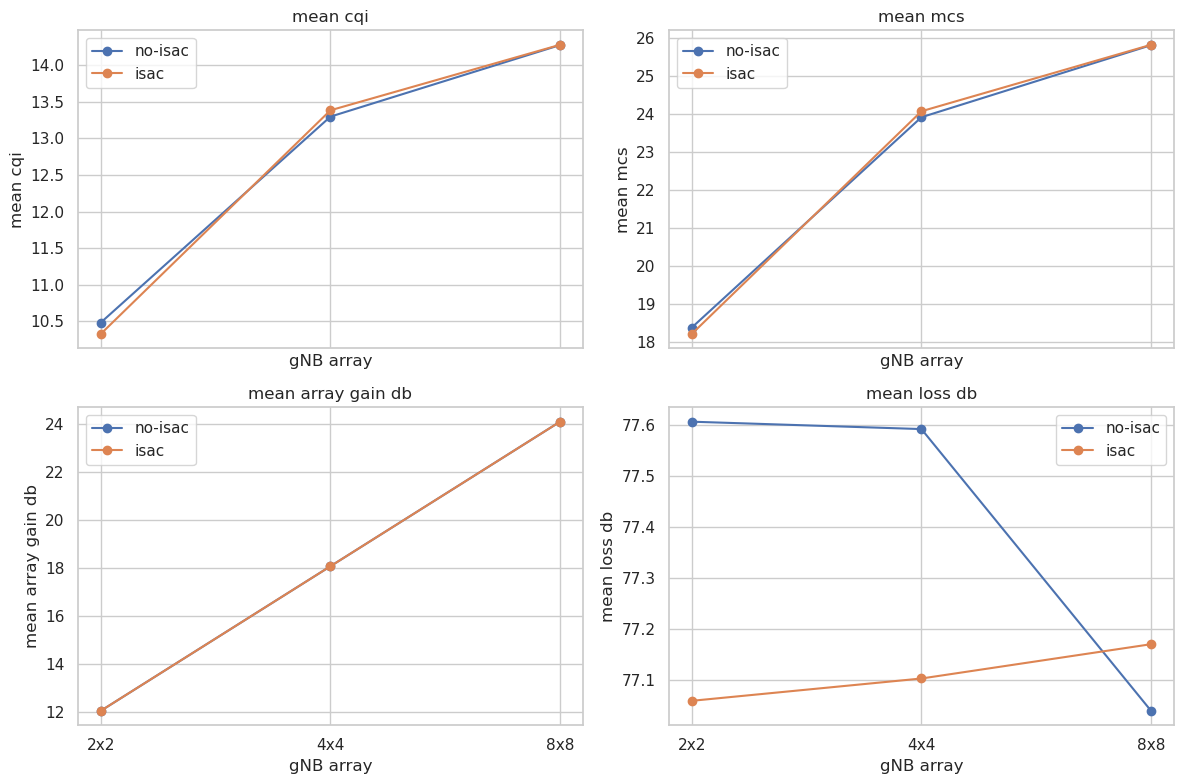

In [7]:
metrics = ["mean_cqi", "mean_mcs", "mean_array_gain_db", "mean_loss_db"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.ravel(), metrics):
    for mode, group in radio_summary.groupby("mode", observed=True):
        group = group.sort_values("array_size")
        ax.plot(group["array"].astype(str), group[metric], marker="o", label=str(mode))
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("gNB array")
    ax.set_ylabel(metric.replace("_", " "))
    ax.legend()
fig.tight_layout()
plt.show()

## ISAC Sensing Summary

Raw detection count can overcount near-duplicate detections. The deduplicated count below bins detections by `TrackId`, time window, and approximate position. Adjust the bin sizes if your sensing model changes.

In [8]:
def summarize_sensing(cases: pd.DataFrame, time_bin_s: float = 0.5, space_bin_m: float = 0.5) -> pd.DataFrame:
    rows = []
    for case in cases.itertuples(index=False):
        sensing = read_csv(Path(case.path) / "sensing_stats.csv")
        if sensing.empty or "DetectionIndex" not in sensing:
            raw = 0
            dedup = 0
            tracks = 0
        else:
            sensing = sensing[sensing["DetectionIndex"].notna()].copy()
            raw = len(sensing)
            if raw:
                sensing["time_bin"] = (sensing["Time_s"] / time_bin_s).round().astype(int)
                sensing["x_bin"] = (sensing["X"] / space_bin_m).round().astype(int)
                sensing["y_bin"] = (sensing["Y"] / space_bin_m).round().astype(int)
                dedup = sensing[["TrackId", "time_bin", "x_bin", "y_bin"]].drop_duplicates().shape[0]
                tracks = sensing["TrackId"].nunique()
            else:
                dedup = 0
                tracks = 0
        rows.append({
            "mode": case.mode,
            "array": case.array,
            "array_size": case.array_size,
            "raw_detections": raw,
            "dedup_detections": dedup,
            "detected_tracks": tracks,
        })
    summary = pd.DataFrame(rows)
    summary["mode"] = pd.Categorical(summary["mode"], MODE_ORDER, ordered=True)
    summary["array"] = pd.Categorical(summary["array"], ARRAY_ORDER, ordered=True)
    return summary.sort_values(["mode", "array_size"]).reset_index(drop=True)


sensing_summary = summarize_sensing(cases)
sensing_summary

,mode,array,array_size,raw_detections,dedup_detections,detected_tracks
0,no-isac,2x2,4,0,0,0
1,no-isac,4x4,16,0,0,0
2,no-isac,8x8,64,0,0,0
3,isac,2x2,4,24,20,2
4,isac,4x4,16,80,69,2
5,isac,8x8,64,250,101,2


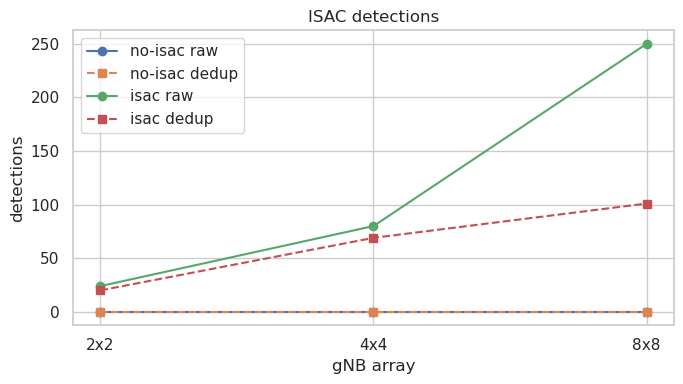

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for mode, group in sensing_summary.groupby("mode", observed=True):
    group = group.sort_values("array_size")
    ax.plot(group["array"].astype(str), group["raw_detections"], marker="o", label=f"{mode} raw")
    ax.plot(group["array"].astype(str), group["dedup_detections"], marker="s", linestyle="--", label=f"{mode} dedup")
ax.set_title("ISAC detections")
ax.set_xlabel("gNB array")
ax.set_ylabel("detections")
ax.legend()
fig.tight_layout()
plt.show()

## Robot Workflow Summary

Use this table to explain why robot flow goodput may not be monotonic. If command publish/receive counts differ strongly between cases, the flow comparison includes application feedback effects, not just radio effects.

In [10]:
def summarize_robot_tasks(cases: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for case in cases.itertuples(index=False):
        tasks = read_csv(Path(case.path) / "robot_task_stats.csv")
        if tasks.empty:
            continue
        numeric = [c for c in tasks.columns if c not in {"Robot"}]
        totals = tasks[numeric].sum(numeric_only=True).to_dict()
        totals.update({"mode": case.mode, "array": case.array, "array_size": case.array_size, "robots": len(tasks)})
        rows.append(totals)
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary
    summary["mode"] = pd.Categorical(summary["mode"], MODE_ORDER, ordered=True)
    summary["array"] = pd.Categorical(summary["array"], ARRAY_ORDER, ordered=True)
    return summary.sort_values(["mode", "array_size"]).reset_index(drop=True)


robot_task_summary = summarize_robot_tasks(cases)
robot_task_summary

,UeIndex,ControllerCommandPublishes,RobotCommandReceives,PickupComplete,StoreComplete,RetrieveComplete,DropComplete,mode,array,array_size,robots
0,15,394,242,4,3,4,3,no-isac,2x2,4,3
1,15,43,77,5,3,6,7,no-isac,4x4,16,3
2,15,16,58,5,3,4,4,no-isac,8x8,64,3
3,15,22,40,5,4,5,4,isac,2x2,4,3
4,15,16,55,5,3,4,4,isac,4x4,16,3
5,15,16,58,5,3,4,4,isac,8x8,64,3


In [11]:
if not robot_task_summary.empty:
    cols = [
        "ControllerCommandPublishes",
        "RobotCommandReceives",
        "PickupComplete",
        "StoreComplete",
        "RetrieveComplete",
        "DropComplete",
    ]
    display(robot_task_summary[["mode", "array"] + [c for c in cols if c in robot_task_summary]].round(3))

,mode,array,ControllerCommandPublishes,RobotCommandReceives,PickupComplete,StoreComplete,RetrieveComplete,DropComplete
0,no-isac,2x2,394,242,4,3,4,3
1,no-isac,4x4,43,77,5,3,6,7
2,no-isac,8x8,16,58,5,3,4,4
3,isac,2x2,22,40,5,4,5,4
4,isac,4x4,16,55,5,3,4,4
5,isac,8x8,16,58,5,3,4,4


## Headline Tables

The first table is the recommended paper/demo headline table. The second table is the diagnostic monotonicity check.

In [12]:
static = flow_summary[flow_summary["flow_class"] == "static"][["mode", "array", "array_size", "goodput_kbps", "delivery_pct"]].rename(columns={
    "goodput_kbps": "static_goodput_kbps",
    "delivery_pct": "static_delivery_pct",
})
robot = flow_summary[flow_summary["flow_class"] == "robot"][["mode", "array", "array_size", "goodput_kbps", "delivery_pct"]].rename(columns={
    "goodput_kbps": "robot_goodput_kbps",
    "delivery_pct": "robot_delivery_pct",
})
headline = (
    static
    .merge(robot, on=["mode", "array", "array_size"], how="outer")
    .merge(radio_summary[["mode", "array", "array_size", "mean_cqi", "mean_mcs", "mean_array_gain_db", "mean_loss_db"]], on=["mode", "array", "array_size"], how="left")
    .merge(sensing_summary[["mode", "array", "array_size", "raw_detections", "dedup_detections"]], on=["mode", "array", "array_size"], how="left")
    .sort_values(["mode", "array_size"])
)
headline.round(3)

,mode,array,array_size,static_goodput_kbps,static_delivery_pct,robot_goodput_kbps,robot_delivery_pct,mean_cqi,mean_mcs,mean_array_gain_db,mean_loss_db,raw_detections,dedup_detections
0,no-isac,2x2,4,25395.03,99.264,23259.71,90.918,10.485,18.372,12.041,77.607,0,0
1,no-isac,4x4,16,25576.19,99.972,19499.77,76.221,13.298,23.912,18.062,77.593,0,0
2,no-isac,8x8,64,25581.35,99.992,21744.45,84.995,14.276,25.810,24.082,77.039,0,0
3,isac,2x2,4,25398.17,99.276,21023.93,82.179,10.330,18.204,12.041,77.059,24,20
4,isac,4x4,16,25576.61,99.974,21819.44,85.288,13.385,24.069,18.062,77.103,80,69
5,isac,8x8,64,25580.93,99.991,21711.61,84.866,14.280,25.820,24.082,77.170,250,101


In [13]:
check_metrics = [
    "static_goodput_kbps",
    "static_delivery_pct",
    "robot_goodput_kbps",
    "robot_delivery_pct",
    "mean_cqi",
    "mean_mcs",
    "mean_array_gain_db",
    "raw_detections",
    "dedup_detections",
]
checks = []
for mode, group in headline.groupby("mode", observed=True):
    group = group.sort_values("array_size")
    for metric in check_metrics:
        if metric not in group:
            continue
        checks.append({
            "mode": mode,
            "metric": metric,
            "values": " -> ".join(f"{v:.3f}" for v in group[metric]),
            "monotonic_non_decreasing": monotonic_non_decreasing(group[metric].tolist()),
        })
monotonicity = pd.DataFrame(checks)
monotonicity

,mode,metric,values,monotonic_non_decreasing
0,no-isac,static_goodput_kbps,25395.030 -> 25576.190 -> 25581.350,True
1,no-isac,static_delivery_pct,99.264 -> 99.972 -> 99.992,True
2,no-isac,robot_goodput_kbps,23259.710 -> 19499.770 -> 21744.450,False
3,no-isac,robot_delivery_pct,90.918 -> 76.221 -> 84.995,False
4,no-isac,mean_cqi,10.485 -> 13.298 -> 14.276,True
5,no-isac,mean_mcs,18.372 -> 23.912 -> 25.810,True
6,no-isac,mean_array_gain_db,12.041 -> 18.062 -> 24.082,True
7,no-isac,raw_detections,0.000 -> 0.000 -> 0.000,True
8,no-isac,dedup_detections,0.000 -> 0.000 -> 0.000,True
9,isac,static_goodput_kbps,25398.170 -> 25576.610 -> 25580.930,True


## Interpretation Template

Use this wording when writing up the result:

> Larger gNB arrays improve the radio-link metrics, including CQI, MCS, and effective array gain. Static benchmark flows show the expected improvement or saturation trend. Full robot-flow goodput is reported separately because mobile robots introduce time-varying geometry and workflow feedback; therefore aggregate application goodput is not expected to be strictly monotonic in the full mission scenario. ISAC benefit is evaluated through sensing detections/tracking metrics rather than through aggregate flow goodput alone.

In [14]:
# Optional: export tables for reports.
out_dir = RESULT_DIR / "analysis_tables"
out_dir.mkdir(exist_ok=True)
headline.to_csv(out_dir / "headline_static_robot_radio_sensing.csv", index=False)
flow_summary.to_csv(out_dir / "flow_summary_by_class.csv", index=False)
radio_summary.to_csv(out_dir / "radio_summary.csv", index=False)
sensing_summary.to_csv(out_dir / "sensing_summary.csv", index=False)
robot_task_summary.to_csv(out_dir / "robot_task_summary.csv", index=False)
monotonicity.to_csv(out_dir / "monotonicity_checks.csv", index=False)
out_dir

PosixPath('/home/aung/code/docte6g/results/warehouse-v3-180s/analysis_tables')